Pericenter at: 205224.94034923517 [pc]
time at pericenter: 118.45637583892618 [Tsim]
velocity at pericenter: 35632.00403241748 [Vsim]
Ram pressure at pericenter: 43209.96705133127


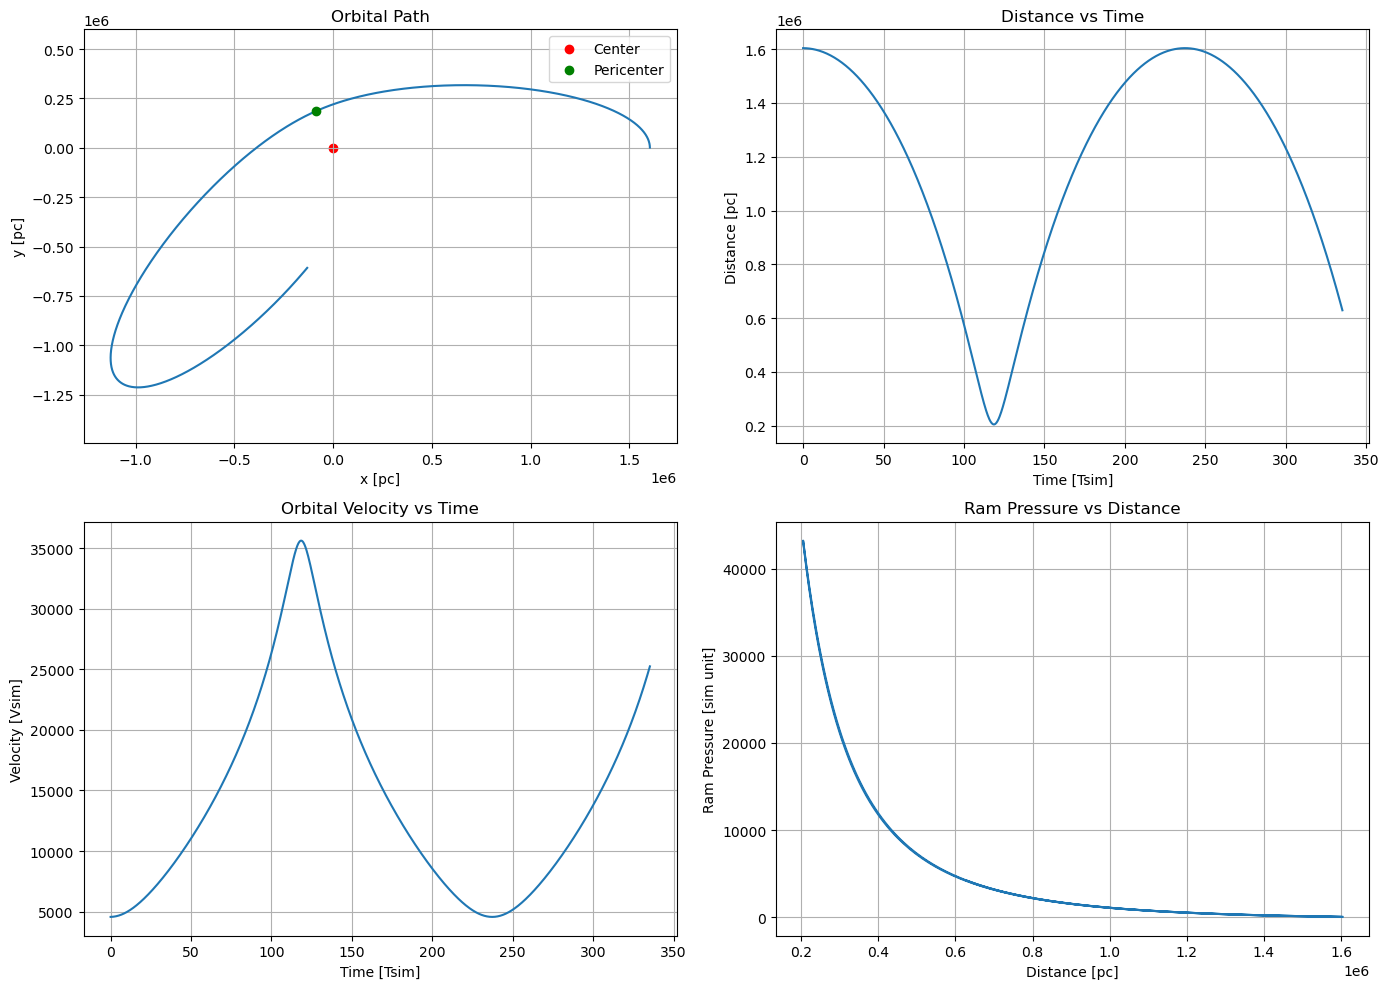

Low Mass Galaxy
Stripping begins at t = 97.6510067114094 [Tsim]
Distance from the center r 629710.1137326561 [pc]
Massive Galaxy
Stripping begins at t = 102.01342281879195 [Tsim]
Distance from the center r 529545.0031373923 [pc]


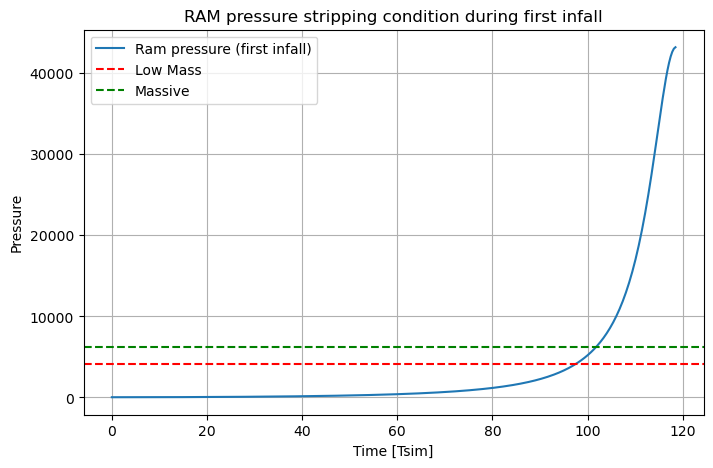

In [28]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u
import astropy.constants as const

# simulation arrays
x_array, y_array, z_array, r_array = [], [], [], []
vx_array, vy_array, vz_array, v_array = [], [], [], []
t_array = []

# G = 1 Units

G = 1
Msim = 1 # Msun Simulation mass
Lsim = 1 # pc distance conversion
Tsim = 14.9 # Myr
Vsim = 0.0658 # km/s

#time steps

t = 0
steps = 1000
total_time = 5000/Tsim # in Tsim units
dt = total_time / steps


# NFW PROFILE

pc = 3.085677581491367e+16 # parsec in meters
Msun = 1.988409870698051e+30 # solar mass in kg
rhoNFW = 9.8E-27 # kg/m³ at z = 0
M200 = 5E14 * Msim # simulation units
c = 4 # NFW Halo concentration

rho_sim = (rhoNFW * (pc**3) )/ Msun
R200 = ((3 * M200) / (4 * np.pi * 200 * rho_sim))**(1/3) 
g = 1 / (np.log(1+c)-(c/(c+1))) 
r_s = R200 / c

# orbital sim for NFW
s_0 = 1 # R200/R200
M_enc0 = M200 * g * (np.log(1 + c*s_0) - (c*s_0)/(1 + c*s_0))
v_c = np.sqrt(G * M_enc0 / R200)

T200 = 2 * np.pi * R200 / v_c

#functions
def dphi_point(r):
    return G * Msim / r**2
def dphi_nfw(r):
    s = r / R200
    M_enc = M200 * g * (np.log(1 + c*s) - (c*s)/(1 + c*s))
    return G * M_enc / r**2


# Initial position and velocities
# Choose potential point mass or NFW

#change velocities 
v_tan_kms = 300
v_rad_kms = 0

v_tan = v_tan_kms / Vsim 
v_rad = v_rad_kms / Vsim

(x,y,z) = (R200,0,0)
(vx,vy,vz) = (v_rad,v_tan,0)
potential = dphi_nfw

#Loop starts
for i in range(steps):
    
    #position
    r = np.sqrt(x**2 + y**2 + z**2)

    dphi = potential(r)

    #acceleration
    ax = -dphi * (x / r)
    ay = -dphi * (y / r)
    az = -dphi * (z / r)

    #velocities updates
    vx += ax * dt
    vy += ay * dt
    vz += az * dt
    
    v = np.sqrt(vx**2 + vy**2 + vz**2)

    #position and time updates
    x += vx * dt
    y += vy * dt
    z += vz * dt
    t = i * dt

    x_array.append(x)
    y_array.append(y)
    z_array.append(z)
    r_array.append(r)
    vx_array.append(vx)
    vy_array.append(vy)
    vz_array.append(vz)
    v_array.append(v)
    t_array.append(t)
    

if potential == dphi_point:

    #perihelion, aphelion, semi major axis calculation and third kepler's law comprobation 
    r_peri = np.min(r_array) #pc
    r_apo = np.max(r_array) #pc
    semi_major = (r_peri + r_apo)*0.5 #pc
    period = ((4*(np.pi**2)*semi_major**3)/(G*Msim))**(1/2) #Tsim

    #Subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))
    
    #Orbit
    ax1.plot(x_array,y_array)
    ax1.scatter(0, 0, color='red')
    ax1.set_xlabel('x[pc]')
    ax1.set_ylabel('y[pc]')
    ax1.axis('equal')
    ax1.grid()

    #Distance vs Time
    ax2.plot(t_array, r_array)
    ax2.axvline(x=period, color='r', linestyle='--', label=f'Period = {period:.2f} Tsim')
    ax2.set_xlabel('Time')
    ax2.set_ylabel('Distance')
    ax2.grid()
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

    print('semi-major axis:',semi_major, '[pc]')
    print('r_peri',r_peri,'[pc]','r_apo',r_apo,'[pc]')
    print('Period:', period,'[Tsim]')


elif potential == dphi_nfw: 

    r_array = np.array(r_array)
    v_orb = np.array(v_array)
    dr = np.diff(r_array)

    peri_indices = np.where((dr[:-1] < 0) & (dr[1:] > 0))[0]
    n_peri = peri_indices[0] + 1
    
    v_peri = v_array[n_peri]
    t_peri = t_array[n_peri]
    r_peri = r_array[n_peri]
    
 
    pc_cm = 3.0856775814913674e18 # parsec in cm
    Msun_g = 1.988409870698051e33 # solar mass in g
    rho_0 = 2e-26  # g/cm³
    rho_0sim = rho_0 * (pc_cm**3) / Msun_g # Simulation units
    beta = 0.5
    r_core = 50000 # pc

    rho_icm = rho_0sim * (1 + (r_array / r_core)**2)**(-3*beta/2)
    
    P_rps = rho_icm* v_orb**2


    # Pstrip = 2 pi G sigma star sigma gas 
    def P_strip(Mstar, Mgas, r_d):
        return G * Mstar * Mgas / (2 * np.pi * r_d**4)

    # galaxy models
    Mstar_low = 1e9
    Mgas_low = 1e9
    rd_low = 2500

    Mstar_massive = 1e10
    Mgas_massive = 1e9
    rd_massive = 4000

    Pstrip_low = P_strip(Mstar_low, Mgas_low, rd_low)
    Pstrip_massive = P_strip(Mstar_massive, Mgas_massive, rd_massive)

    P_rps_infall = P_rps[:n_peri+1]
    t_infall = t_array[:n_peri+1]
    r_infall = r_array[:n_peri+1]

    print('Pericenter at:', r_peri, '[pc]')
    print('time at pericenter:', t_peri, '[Tsim]')
    print('velocity at pericenter:', v_peri, '[Vsim]')
    print('Ram pressure at pericenter:', P_rps[n_peri])
        
    fig, axs = plt.subplots(2, 2, figsize=(14, 10))
    # orbit 
    axs[0,0].plot(x_array, y_array)
    axs[0,0].scatter(0, 0, color='red', label='Center')
    axs[0,0].scatter(x_array[n_peri], y_array[n_peri], color='green', label='Pericenter', zorder=5)
    axs[0,0].set_xlabel('x [pc]')
    axs[0,0].set_ylabel('y [pc]')
    axs[0,0].set_title('Orbital Path')
    axs[0,0].axis('equal')
    axs[0,0].grid(True)
    axs[0,0].legend()

    # distance vs time 
    axs[0,1].plot(t_array, r_array)
    axs[0,1].set_xlabel('Time [Tsim]')
    axs[0,1].set_ylabel('Distance [pc]')
    axs[0,1].set_title('Distance vs Time')
    axs[0,1].grid(True)

    # orbital velocity vs time 
    axs[1,0].plot(t_array, v_array)
    axs[1,0].set_xlabel('Time [Tsim]')
    axs[1,0].set_ylabel('Velocity [Vsim]')
    axs[1,0].set_title('Orbital Velocity vs Time')
    axs[1,0].grid(True)

    # RAM pressure vs distance
    axs[1,1].plot(r_array, P_rps)
    axs[1,1].set_xlabel('Distance [pc]')
    axs[1,1].set_ylabel('Ram Pressure [sim unit]')
    axs[1,1].set_title('Ram Pressure vs Distance')
    axs[1,1].grid(True)

    plt.tight_layout()
    plt.show()

    low_mass = P_rps[:n_peri+1] > Pstrip_low
    
    if np.any(low_mass):
        number_low = np.where(low_mass)[0][0]
        print('Low Mass Galaxy')
        print('Stripping begins at t =', t_array[number_low], '[Tsim]')
        print('Distance from the center r', r_array[number_low], '[pc]')
    else:
        print('The low mass galaxy does not lose gas during the first infall') 

    massive = P_rps[:n_peri+1] > Pstrip_massive
    
    if np.any(massive):
        number_massive = np.where(massive)[0][0]
        print('Massive Galaxy')
        print('Stripping begins at t =', t_array[number_massive], '[Tsim]')
        print('Distance from the center r', r_array[number_massive], '[pc]')
    else:
        print('The massive galaxy does not lose gas during the first infall')

    
    plt.figure(figsize=(8,5))
    plt.plot(t_infall, P_rps_infall, label='Ram pressure (first infall)')
    plt.axhline(y=Pstrip_low, color='r', linestyle='--', label='Low Mass')
    plt.axhline(y=Pstrip_massive, color='g', linestyle='--', label='Massive')
    plt.xlabel('Time [Tsim]')
    plt.ylabel('Pressure')
    plt.title('RAM pressure stripping condition during first infall')
    plt.legend()
    plt.grid()
    plt.show()

In [16]:
mask_low = P_rps[:n_peri+1] > Pstrip_low

In [18]:
mask_massive

array([False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False,